# Pipeline

load data → features → target → split → models → evaluation → plots

# Imports

In [1]:
import pandas as pd
import numpy as np
import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Data load

In [2]:
files = glob.glob("../data/raw/historical/*.parquet")

df_list = []

for file in files:
    df = pd.read_parquet(file)
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)
df = df.sort_values(["city", "time"])

df.head()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,apparent_temperature_max,relative_humidity_2m_mean,weather_code,city
0,2020-01-01,11.4,4.4,0.0,11.4,8.8,88,3,Baku
1,2020-01-02,8.6,2.7,0.3,33.0,3.2,86,51,Baku
2,2020-01-03,7.6,3.4,1.4,21.7,3.3,84,51,Baku
3,2020-01-04,8.4,5.7,0.2,22.7,4.6,81,51,Baku
4,2020-01-05,7.7,5.8,2.6,12.6,6.4,94,53,Baku


# Basic cleaning

In [3]:
df = df.dropna().copy()

print(df.shape)

(10960, 9)


# Feature engineering

In [4]:
df = df.sort_values(["city", "time"])

## Calendar

In [5]:
df["month"] = df["time"].dt.month
df["day_of_month"] = df["time"].dt.day
df["day_of_year"] = df["time"].dt.dayofyear

## Lag features

In [6]:
df["temperature_lag_1"] = df.groupby("city")["temperature_2m_max"].shift(1)

df["precipitation_lag_1"] = df.groupby("city")["precipitation_sum"].shift(1)

df["wind_lag_1"] = df.groupby("city")["wind_speed_10m_max"].shift(1)

df["humidity_lag_1"] = df.groupby("city")["relative_humidity_2m_mean"].shift(1)

## Diff feature

In [7]:
df["temp_diff_1"] = df["temperature_2m_max"] - df["temperature_lag_1"]

## Rolling features

In [8]:
df["temperature_3d_avg"] = df.groupby("city")["temperature_2m_max"].rolling(3).mean().reset_index(0, drop=True)
df["temp_3d_std"] = df.groupby("city")["temperature_2m_max"].transform(lambda x: x.rolling(3).std())
df["precipitation_7d_sum"] = df.groupby("city")["precipitation_sum"].rolling(7).sum().reset_index(0, drop=True)
df["wind_3d_avg"] = df.groupby("city")["wind_speed_10m_max"].rolling(3).mean().reset_index(0, drop=True)
df["humidity_7d_avg"] = df.groupby("city")["relative_humidity_2m_mean"].rolling(7).mean().reset_index(0, drop=True)

## Clean NaN after Lag features

In [9]:
df = df.dropna().copy()

# Target

In [10]:
HORIZON = 7

targets = [
    "temperature_2m_max",
    "precipitation_sum",
    "wind_speed_10m_max",
    "relative_humidity_2m_mean"
]

for col in targets:
    df[f"{col}_target"] = df.groupby("city")[col].shift(-HORIZON)

df = df.dropna().copy()

## Encoding cities

In [11]:
le = LabelEncoder()
df["city_encoded"] = le.fit_transform(df["city"])

## Time-based split

In [12]:
feature_cols = [
    "city_encoded",
    "month",
    "day_of_month",
    "temperature_lag_1",
    "precipitation_lag_1",
    "wind_lag_1",
    "humidity_lag_1",
    "temperature_3d_avg",
    "precipitation_7d_sum",
    "wind_3d_avg",
    "humidity_7d_avg"
]

target_cols = [f"{col}_target" for col in targets]

X = df[feature_cols]
Y = df[target_cols]

split_date = "2024-01-01"

train = df[df["time"] < split_date]
test  = df[df["time"] >= split_date]

X_train = train[feature_cols]
Y_train = train[target_cols]

X_test = test[feature_cols]
Y_test = test[target_cols]

# Models

## Dummy (baseline)

In [13]:
dummy = MultiOutputRegressor(DummyRegressor(strategy="mean"))
dummy.fit(X_train, Y_train)
Y_pred_dummy = dummy.predict(X_test)

## Ridge

In [14]:
ridge = MultiOutputRegressor(Ridge())
ridge.fit(X_train, Y_train)
Y_pred_ridge = ridge.predict(X_test)

## Random Forest

In [15]:
rf = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
rf.fit(X_train, Y_train)
Y_pred_rf = rf.predict(X_test)

# Validation

In [16]:
def model_metrics(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

results = [
    model_metrics(Y_test, Y_pred_dummy, "Dummy"),
    model_metrics(Y_test, Y_pred_ridge, "Ridge"),
    model_metrics(Y_test, Y_pred_rf, "Random Forest")
]

results_df = pd.DataFrame(results)
results_df

,model,MAE,RMSE,R2
0,Dummy,6.962193,9.643026,-0.012886
1,Ridge,5.090740,7.600318,0.311768
2,Random Forest,5.064397,7.562726,0.293473


# Visualisation

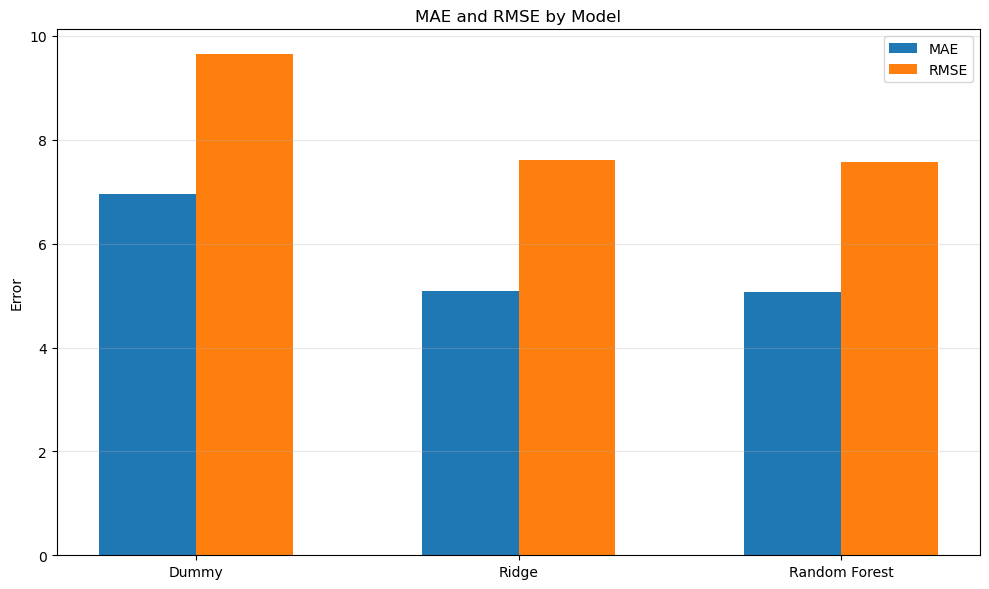

In [17]:
metrics_to_plot = ["MAE", "RMSE", "R2"]

x = np.arange(len(results_df["model"]))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - 0.15, results_df["MAE"], 0.3, label="MAE")
ax.bar(x + 0.15, results_df["RMSE"], 0.3, label="RMSE")

ax.set_xticks(x)
ax.set_xticklabels(results_df["model"])
ax.set_ylabel("Error")
ax.set_title("MAE and RMSE by Model")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

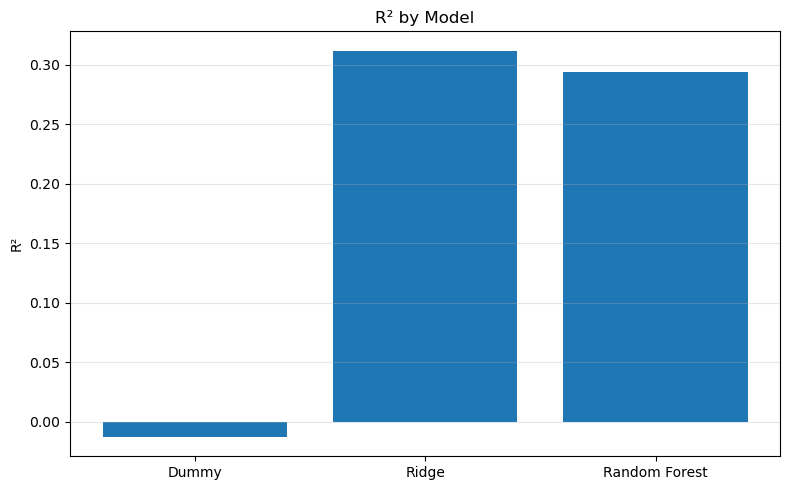

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(results_df["model"], results_df["R2"])
ax.set_ylabel("R²")
ax.set_title("R² by Model")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

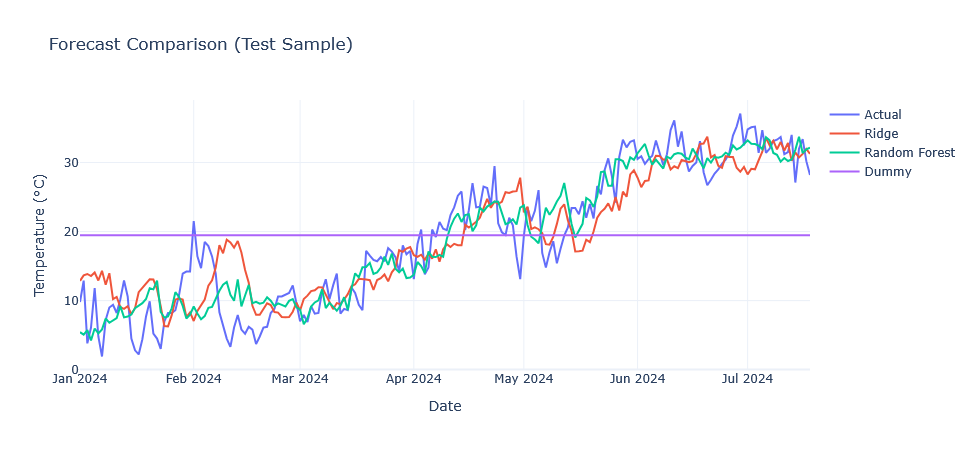

In [29]:
n = 200
target_idx = 0

# берём даты из test
dates = test["time"].iloc[:n]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=dates,
    y=Y_test.iloc[:n, target_idx],
    mode='lines',
    name='Actual'
))

fig.add_trace(go.Scatter(
    x=dates,
    y=Y_pred_ridge[:n, target_idx],
    mode='lines',
    name='Ridge'
))

fig.add_trace(go.Scatter(
    x=dates,
    y=Y_pred_rf[:n, target_idx],
    mode='lines',
    name='Random Forest'
))

fig.add_trace(go.Scatter(
    x=dates,
    y=Y_pred_dummy[:n, target_idx],
    mode='lines',
    name='Dummy'
))

fig.update_layout(
    title="Forecast Comparison (Test Sample)",
    xaxis_title="Date",
    yaxis_title="Temperature (°C)",
    template="plotly_white",
    width=900,
    height=450,
    hovermode="x unified"
)

fig.show()

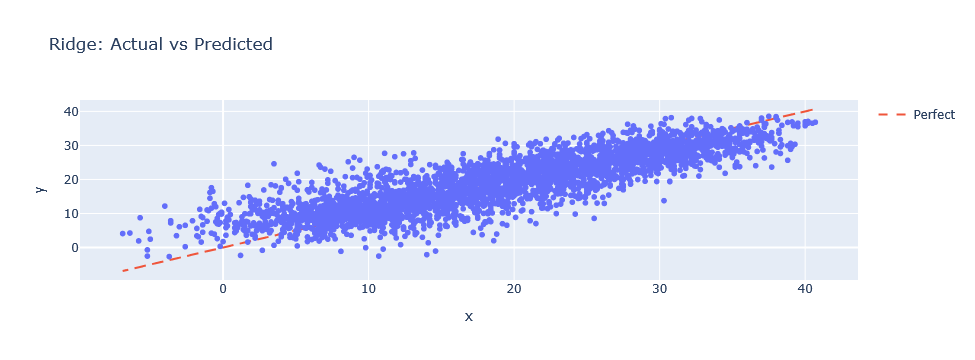

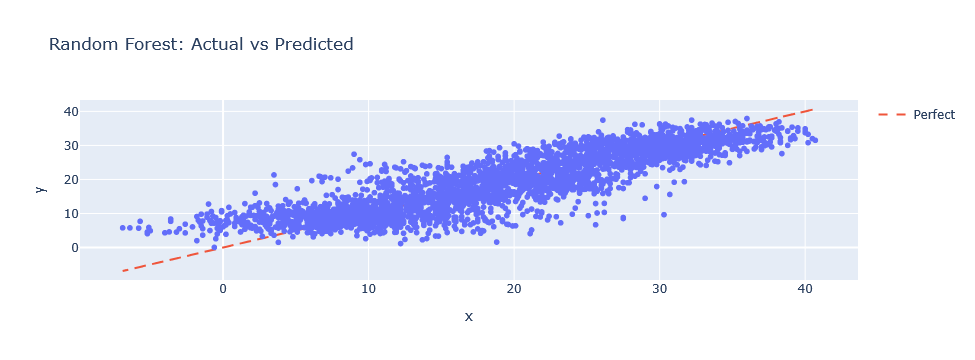

In [26]:
models = {
    "Ridge": Y_pred_ridge[:, target_idx],
    "Random Forest": Y_pred_rf[:, target_idx]
}

for name, preds in models.items():
    fig = px.scatter(
        x=Y_test.iloc[:, target_idx],
        y=preds,
        title=f"{name}: Actual vs Predicted"
    )

    fig.add_trace(go.Scatter(
        x=Y_test.iloc[:, target_idx],
        y=Y_test.iloc[:, target_idx],
        mode="lines",
        name="Perfect",
        line=dict(dash="dash")
    ))

    fig.show()